# 220 — The classical MHC in the QfO region run: what is on the map

**Question:** the midi run searched every human chromosome 6 protein against nine whole
proteomes. Before reading any result off it, what does it actually cover inside the MHC,
and what can each target proteome possibly contain?

The MHC is the wrong region to walk into without a map. It is 7.6 Mb holding several
unrelated stories at once: a class I and a class II region whose genes are jawed-vertebrate
inventions ~500 Mya old, separated by a class III region that is not immunoglobulin at all
and whose genes (complement, TNF, HSP70) run back to bacteria. A single "MHC recall" number
averages those together and means nothing.

This notebook fixes three things the later notebooks depend on:

1. where each chr6 query gene sits, and which xMHC sub-region it falls in
2. which Pfam domains the MHC genes actually carry — the run's own truth set, not recall
3. what is *reachable*: which of those families exist at all in each target proteome

Companion notebooks: [221](./221_mhc_cross_species_detection_depth.ipynb) (how far back each
gene is detectable, and by which tool), [222](./222_mhc_synteny_target_side.ipynb) (where the
hits land in the target genome), [223](./223_mhc_platform_vs_ig_domain.ipynb) (the
peptide-binding groove versus the Ig domain in the same molecule).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import polars as pl

import mhc_region_utils as mu
import ortholog_analysis_utils as ou

FIG_DIR = Path("../figures")
FIG_DIR.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight", "font.size": 10})

gene_map = mu.load_chr6_gene_map()
truth = mu.load_human_truth()
gencode6 = pl.read_parquet(mu.CHR6_GENCODE)

window = mu.load_mhc_window(gene_map)
core = gene_map.filter(pl.col("mhc_class").is_not_null())

print(f"chr6 query proteins in the midi run : {gene_map.height:_}")
print(
    f"  with GENCODE v50 coordinates      : {gene_map.filter(pl.col('midpoint').is_not_null()).height:_}"
)
print(f"  inside the extended MHC           : {window.height:_}")
print(f"  curated MHC genes (ou.MHC_CLASSES): {core.height:_}")
print(
    f"human Pfam domain instances scored  : {truth.height:_} "
    f"across {truth['pfam_id'].n_unique():_} families"
)
print(
    f"  on MHC-window genes               : "
    f"{truth.filter(pl.col('accession').is_in(window['accession'].to_list())).height:_}"
)

chr6 query proteins in the midi run : 964
  with GENCODE v50 coordinates      : 957
  inside the extended MHC           : 221
  curated MHC genes (ou.MHC_CLASSES): 24
human Pfam domain instances scored  : 2_358 across 1_086 families
  on MHC-window genes               : 599


## 1. The extended MHC, and where the query set falls inside it

Sub-region boundaries are Horton et al. 2004's xMHC partition in GRCh38 coordinates
(`mu.MHC_SUBREGIONS`), assigned by gene midpoint so a gene straddling a boundary lands on
the side holding most of it. The five-way split is the point: an immunologist reads class I,
class III and class II as three different kinds of gene, and the figure has to keep them
apart.

The bottom panel is the part that matters for every later notebook. The 736 chr6 genes
*outside* the xMHC are not padding — they are the built-in control. The arithmetic closes as
964 = 221 in the window + 736 outside it + 7 with no GENCODE chr6 record under their HGNC
symbol (§4). Any statement of the form
"tool X does badly on the MHC" only means something against how X does on the rest of the
same chromosome, scored the same way in the same run.

shape: (5, 6)
┌───────────────────┬──────────┬──────────┬─────────┬────────────────┬───────────────┐
│ mhc_subregion     ┆ start    ┆ end      ┆ span_mb ┆ n_coding_genes ┆ n_query_genes │
│ ---               ┆ ---      ┆ ---      ┆ ---     ┆ ---            ┆ ---           │
│ str               ┆ i64      ┆ i64      ┆ f64     ┆ u32            ┆ u32           │
╞═══════════════════╪══════════╪══════════╪═════════╪════════════════╪═══════════════╡
│ extended class I  ┆ 25726063 ┆ 29722774 ┆ 4.0     ┆ 116            ┆ 86            │
│ class I           ┆ 29722775 ┆ 31371356 ┆ 1.65    ┆ 46             ┆ 41            │
│ class III         ┆ 31371357 ┆ 32145873 ┆ 0.77    ┆ 58             ┆ 51            │
│ class II          ┆ 32146874 ┆ 33080775 ┆ 0.93    ┆ 32             ┆ 28            │
│ extended class II ┆ 33080776 ┆ 33400644 ┆ 0.32    ┆ 17             ┆ 15            │
└───────────────────┴──────────┴──────────┴─────────┴────────────────┴───────────────┘

chr6 queries outside the xMH

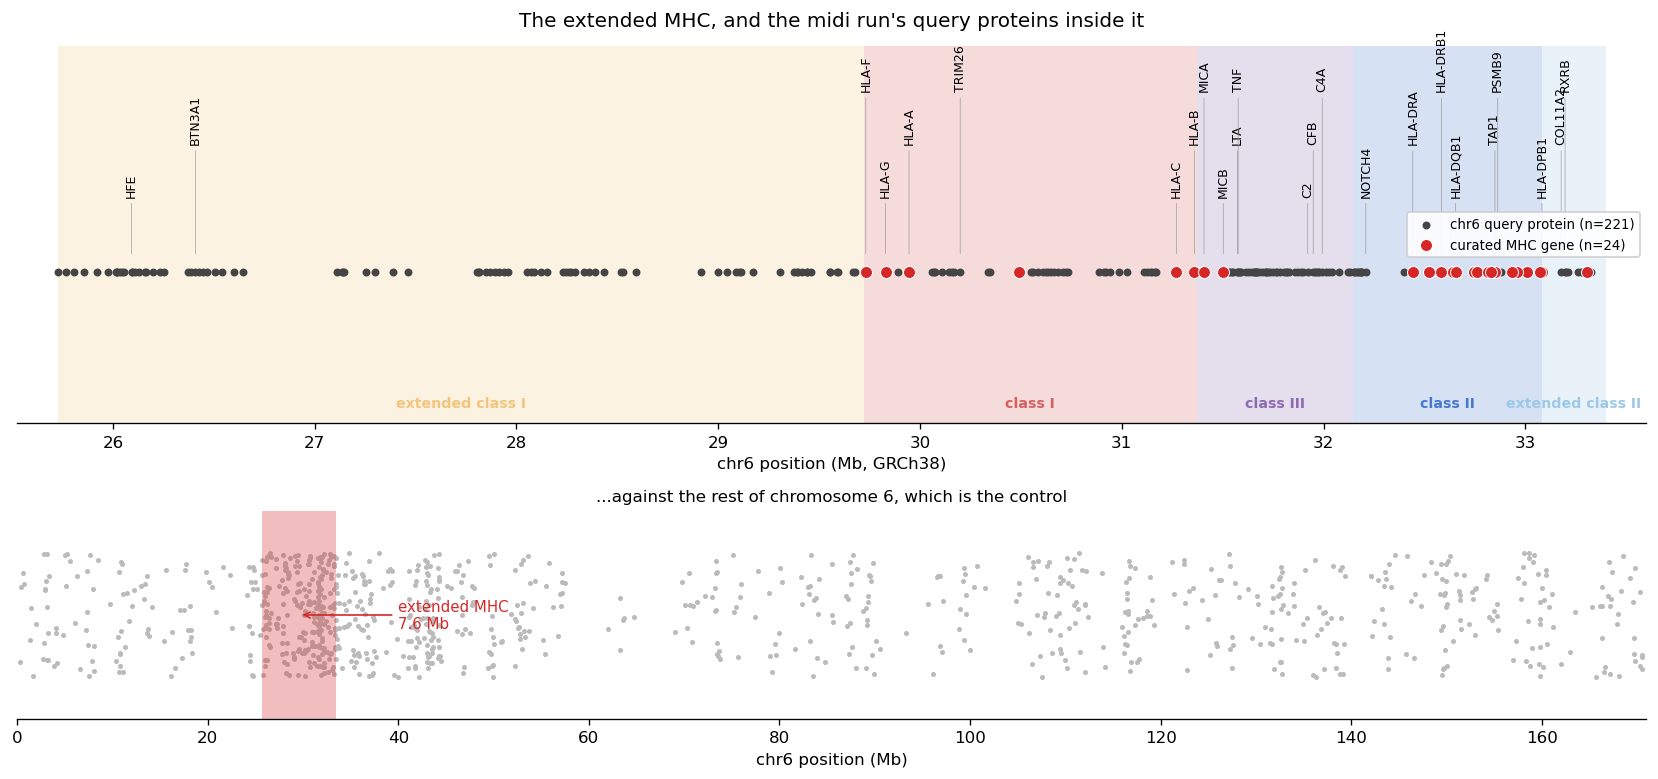

In [2]:
gm = gene_map.filter(pl.col("midpoint").is_not_null())
sub_counts = gm.group_by("mhc_subregion").len().rename({"len": "n_query_genes"})
order = mu.MHC_SUBREGION_ORDER
tbl = (
    pl.DataFrame({"mhc_subregion": order})
    .join(sub_counts, on="mhc_subregion", how="left")
    .with_columns(pl.col("n_query_genes").fill_null(0))
    .with_columns(
        start=pl.Series([lo for _, lo, _ in mu.MHC_SUBREGIONS]),
        end=pl.Series([hi for _, _, hi in mu.MHC_SUBREGIONS]),
    )
    .with_columns(span_mb=((pl.col("end") - pl.col("start")) / 1e6).round(2))
)

# All GENCODE protein-coding genes in the window, so "query genes" can be read against
# "genes that are there" rather than against nothing.
g6 = gencode6.filter(pl.col("gene_type") == "protein_coding").with_columns(
    mhc_subregion=mu.assign_subregion(pl.col("midpoint"))
)
tbl = tbl.join(
    g6.group_by("mhc_subregion").len().rename({"len": "n_coding_genes"}),
    on="mhc_subregion",
    how="left",
)
tbl = tbl.select(
    "mhc_subregion", "start", "end", "span_mb", "n_coding_genes", "n_query_genes"
)
with pl.Config(tbl_rows=20, tbl_width_chars=160):
    print(tbl)
print(
    f"\nchr6 queries outside the xMHC (the control set): "
    f"{gm.filter(pl.col('mhc_subregion').is_null()).height:_}"
)

fig, axes = plt.subplots(
    2, 1, figsize=(14, 6.6), gridspec_kw={"height_ratios": [2, 1.1]}
)

# --- top: the xMHC itself, zoomed ---
ax = axes[0]
for name, lo, hi in mu.MHC_SUBREGIONS:
    ax.axvspan(
        lo / 1e6, hi / 1e6, color=mu.MHC_SUBREGION_COLORS[name], alpha=0.22, lw=0
    )
    ax.text(
        (lo + hi) / 2e6,
        0.035,
        name,
        ha="center",
        va="bottom",
        fontsize=8.5,
        color=mu.MHC_SUBREGION_COLORS[name],
        fontweight="bold",
        transform=ax.get_xaxis_transform(),
    )

win = window.filter(pl.col("midpoint").is_not_null())
ax.scatter(
    win["midpoint"].to_numpy() / 1e6,
    np.full(win.height, 0.40),
    s=14,
    color="#444444",
    zorder=3,
    label=f"chr6 query protein (n={win.height})",
)
core_win = core.filter(pl.col("midpoint").is_not_null())
ax.scatter(
    core_win["midpoint"].to_numpy() / 1e6,
    np.full(core_win.height, 0.40),
    s=52,
    color="#D62728",
    zorder=4,
    edgecolor="white",
    linewidth=0.6,
    label=f"curated MHC gene (n={core_win.height})",
)

lm = gencode6.filter(pl.col("gene_name").is_in(list(mu.MHC_LANDMARKS)))
for i, r in enumerate(lm.sort("midpoint").iter_rows(named=True)):
    y = (0.60, 0.74, 0.88)[i % 3]
    ax.annotate(
        r["gene_name"],
        (r["midpoint"] / 1e6, 0.44),
        (r["midpoint"] / 1e6, y),
        ha="center",
        fontsize=7.5,
        rotation=90,
        va="bottom",
        arrowprops=dict(arrowstyle="-", lw=0.4, color="#999999"),
    )
ax.set_xlim(mu.XMHC_START / 1e6 - 0.2, mu.XMHC_END / 1e6 + 0.2)
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_xlabel("chr6 position (Mb, GRCh38)")
ax.set_title("The extended MHC, and the midi run's query proteins inside it", pad=12)
ax.legend(loc="center right", fontsize=8, framealpha=0.9)
for s in ("left", "right", "top"):
    ax.spines[s].set_visible(False)

# --- bottom: the whole chromosome, for scale ---
ax = axes[1]
ax.scatter(
    gm["midpoint"].to_numpy() / 1e6,
    np.random.default_rng(0).uniform(0.2, 0.8, gm.height),
    s=4,
    color="#bbbbbb",
    label=f"chr6 query outside xMHC (n={gm.filter(pl.col('mhc_subregion').is_null()).height})",
)
ax.axvspan(mu.XMHC_START / 1e6, mu.XMHC_END / 1e6, color="#D62728", alpha=0.3, lw=0)
ax.annotate(
    "extended MHC\n7.6 Mb",
    (((mu.XMHC_START + mu.XMHC_END) / 2) / 1e6, 0.5),
    (40, 0.5),
    fontsize=9,
    va="center",
    arrowprops=dict(arrowstyle="->", lw=1.0, color="#D62728"),
    color="#D62728",
)
ax.set_xlim(0, 171)
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_xlabel("chr6 position (Mb)")
ax.set_title("...against the rest of chromosome 6, which is the control", fontsize=10)
for s in ("left", "right", "top"):
    ax.spines[s].set_visible(False)

fig.tight_layout()
fig.savefig(FIG_DIR / "220_mhc_region_map.png", dpi=200)

## 2. Every class I and class II gene carries the same two domains

This is the structure the whole analysis rests on, and it comes from the run's own truth
set rather than from anything asserted here.

Each class I heavy chain is scored as **PF00129** (the α1/α2 peptide-binding platform,
roughly residues 25–203) plus **PF07654** (the C1-set immunoglobulin domain, α3, roughly
211–290). Class II splits the same way: **PF00993** (α1) or **PF00969** (β1) for the
platform half, and PF07654 again for the Ig half.

Those two domains sit in one molecule, get searched in one query, and are scored by one
arm — but they are under completely different selection. The platform holds the
peptide-binding residues and is the most polymorphic coding sequence in the human genome;
the C1-set Ig domain is a conserved fold shared with antibodies, T-cell receptors and
hundreds of other IgSF proteins. Anything that recovers one but not the other is telling
you something specific, and notebook 223 is built on exactly that contrast.

TAP1 and TAP2 are the internal positive control. They sit inside the class II region but are
ABC transporters — PF00664 plus PF00005, a fold shared with *E. coli*. They separate "this
species is too distant for anything" from "this domain is evolving too fast".

Pfam families per curated MHC gene, from human_domain_truth.parquet:
shape: (24, 4)
┌─────────────┬───────────────────┬───────────────────────────────────┬───────────┐
│ hgnc_symbol ┆ mhc_class         ┆ pfam_ids                          ┆ n_domains │
│ ---         ┆ ---               ┆ ---                               ┆ ---       │
│ str         ┆ str               ┆ list[str]                         ┆ u32       │
╞═════════════╪═══════════════════╪═══════════════════════════════════╪═══════════╡
│ HLA-A       ┆ I classical       ┆ ["PF00129", "PF06623", "PF07654"] ┆ 3         │
│ HLA-B       ┆ I classical       ┆ ["PF00129", "PF06623", "PF07654"] ┆ 3         │
│ HLA-C       ┆ I classical       ┆ ["PF00129", "PF06623", "PF07654"] ┆ 3         │
│ HLA-E       ┆ I non-classical   ┆ ["PF00129", "PF06623", "PF07654"] ┆ 3         │
│ HLA-F       ┆ I non-classical   ┆ ["PF00129", "PF07654"]            ┆ 2         │
│ HLA-G       ┆ I non-classical   ┆ ["PF00129", "PF07654"]            ┆ 2   

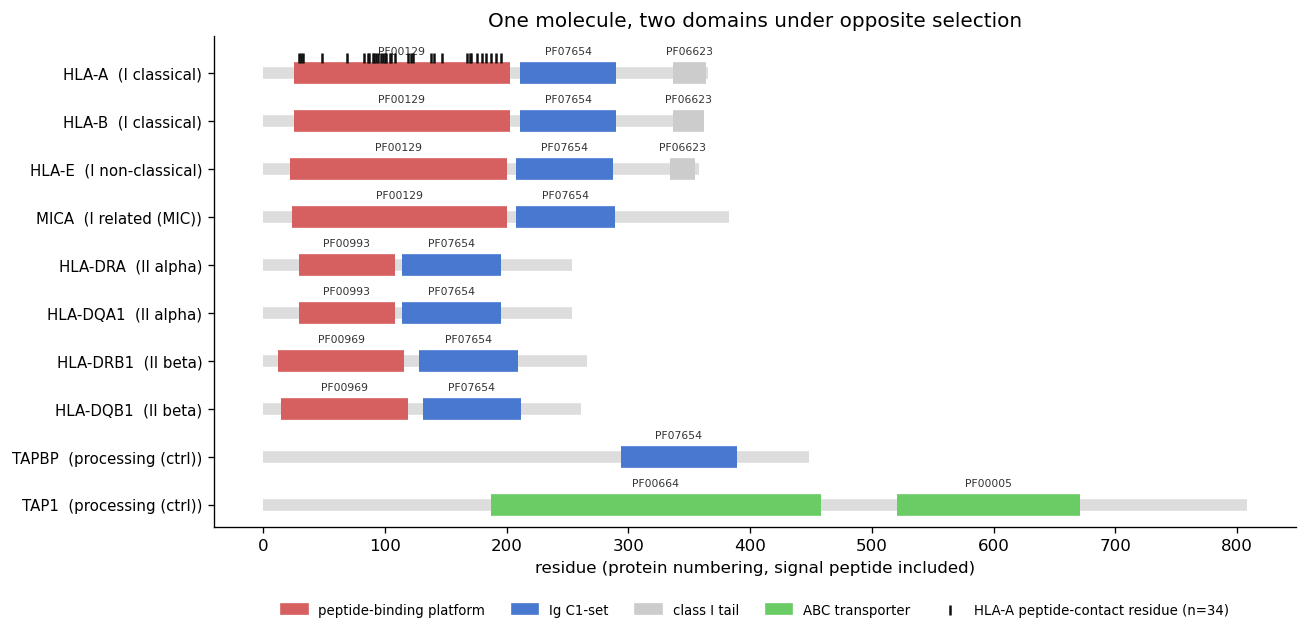

In [3]:
core_truth = truth.join(
    core.select("accession", "hgnc_symbol", "mhc_class"), on="accession", how="inner"
).with_columns(role=mu.domain_role(pl.col("pfam_id")))

per_gene = (
    core_truth.group_by("hgnc_symbol", "mhc_class")
    .agg(pl.col("pfam_id").sort().alias("pfam_ids"), pl.len().alias("n_domains"))
    .sort("mhc_class", "hgnc_symbol")
)
print("Pfam families per curated MHC gene, from human_domain_truth.parquet:")
with pl.Config(tbl_rows=40, fmt_str_lengths=60, tbl_width_chars=150):
    print(per_gene)

print("\nDomain instances by structural role:")
print(core_truth.group_by("role").len().sort("len", descending=True))
print("\nAll platform + Ig pairings present:")
print(
    core_truth.filter(pl.col("role").is_in(["peptide-binding platform", "Ig C1-set"]))
    .group_by("mhc_class", "role", "pfam_id")
    .len()
    .sort("mhc_class", "role")
)

# --- figure: domain architecture, drawn from the truth-set coordinates ---
show = [
    "HLA-A",
    "HLA-B",
    "HLA-E",
    "MICA",
    "HLA-DRA",
    "HLA-DQA1",
    "HLA-DRB1",
    "HLA-DQB1",
    "TAPBP",
    "TAP1",
]
sub = core_truth.filter(pl.col("hgnc_symbol").is_in(show))
fig, ax = plt.subplots(figsize=(11, 5.4))
ylabels = []
for i, sym in enumerate(show):
    rows = sub.filter(pl.col("hgnc_symbol") == sym).sort("domain_start")
    if rows.height == 0:
        continue
    L = rows["protein_length"][0]
    ax.plot([0, L], [i, i], color="#dddddd", lw=7, solid_capstyle="butt", zorder=1)
    for r in rows.iter_rows(named=True):
        colour = mu.DOMAIN_ROLE_COLORS.get(r["role"], "#888888")
        ax.plot(
            [r["domain_start"], r["domain_end"]],
            [i, i],
            color=colour,
            lw=13,
            solid_capstyle="butt",
            zorder=2,
        )
        ax.text(
            (r["domain_start"] + r["domain_end"]) / 2,
            i - 0.34,
            r["pfam_id"],
            ha="center",
            va="bottom",
            fontsize=6.5,
            color="#333333",
        )
    ylabels.append(f"{sym}  ({rows['mhc_class'][0]})")

# HLA-A's peptide-contact residues, from ou.CONTACT_PROT, on the top row only.
ax.scatter(
    ou.CONTACT_PROT,
    np.zeros(len(ou.CONTACT_PROT)) - 0.30,
    marker="|",
    s=34,
    color="#111111",
    zorder=5,
    label=f"HLA-A peptide-contact residue (n={len(ou.CONTACT_PROT)})",
)

ax.set_yticks(range(len(ylabels)))
ax.set_yticklabels(ylabels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("residue (protein numbering, signal peptide included)")
ax.set_title("One molecule, two domains under opposite selection")
handles = [mpatches.Patch(color=c, label=k) for k, c in mu.DOMAIN_ROLE_COLORS.items()]
handles += ax.get_legend_handles_labels()[0]
ax.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.13),
    ncol=5,
    fontsize=8,
    frameon=False,
)
for s in ("right", "top"):
    ax.spines[s].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "220_mhc_domain_architecture.png", dpi=200)

## 3. What each target proteome can possibly contain

A recall number is meaningless without the denominator that goes with it. MHC class I and
class II are jawed-vertebrate inventions; a search of *E. coli* cannot find PF00129 because
*E. coli* has no PF00129. Scoring that as a miss punishes the tool for the phylogeny.

The table below is the honest denominator: for each target proteome, how many instances of
each MHC-relevant Pfam family the run's own domain map contains. `mouse`, `chicken` and
`zebrafish` are the only three targets that can hold a real MHC molecule. From ciona
outward, a hit can only be a more distant relative of the fold — which is a different and
more interesting claim, and notebook 221 keeps the two separated.

shape: (9, 10)
┌─────────────┬──────┬──────────────────┬─────────┬───┬─────────┬─────────┬─────────┬─────────┐
│ species     ┆ mya  ┆ proteome_domains ┆ PF00129 ┆ … ┆ PF07654 ┆ PF06623 ┆ PF00664 ┆ PF00005 │
│ ---         ┆ ---  ┆ ---              ┆ ---     ┆   ┆ ---     ┆ ---     ┆ ---     ┆ ---     │
│ str         ┆ i64  ┆ i64              ┆ i64     ┆   ┆ i64     ┆ i64     ┆ i64     ┆ i64     │
╞═════════════╪══════╪══════════════════╪═════════╪═══╪═════════╪═════════╪═════════╪═════════╡
│ mouse       ┆ 100  ┆ 49998            ┆ 37      ┆ … ┆ 126     ┆ 6       ┆ 39      ┆ 89      │
│ chicken     ┆ 300  ┆ 13421            ┆ 2       ┆ … ┆ 12      ┆ 0       ┆ 8       ┆ 15      │
│ zebrafish   ┆ 430  ┆ 28019            ┆ 6       ┆ … ┆ 32      ┆ 0       ┆ 26      ┆ 45      │
│ ciona       ┆ 550  ┆ 20234            ┆ 0       ┆ … ┆ 0       ┆ 0       ┆ 26      ┆ 52      │
│ fly         ┆ 600  ┆ 22096            ┆ 0       ┆ … ┆ 1       ┆ 0       ┆ 40      ┆ 88      │
│ worm        ┆ 650  ┆ 24

/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_5562/701191730.py:21: RuntimeWarning: divide by zero encountered in log10
  shown = np.where(mat > 0, np.log10(mat), np.nan)


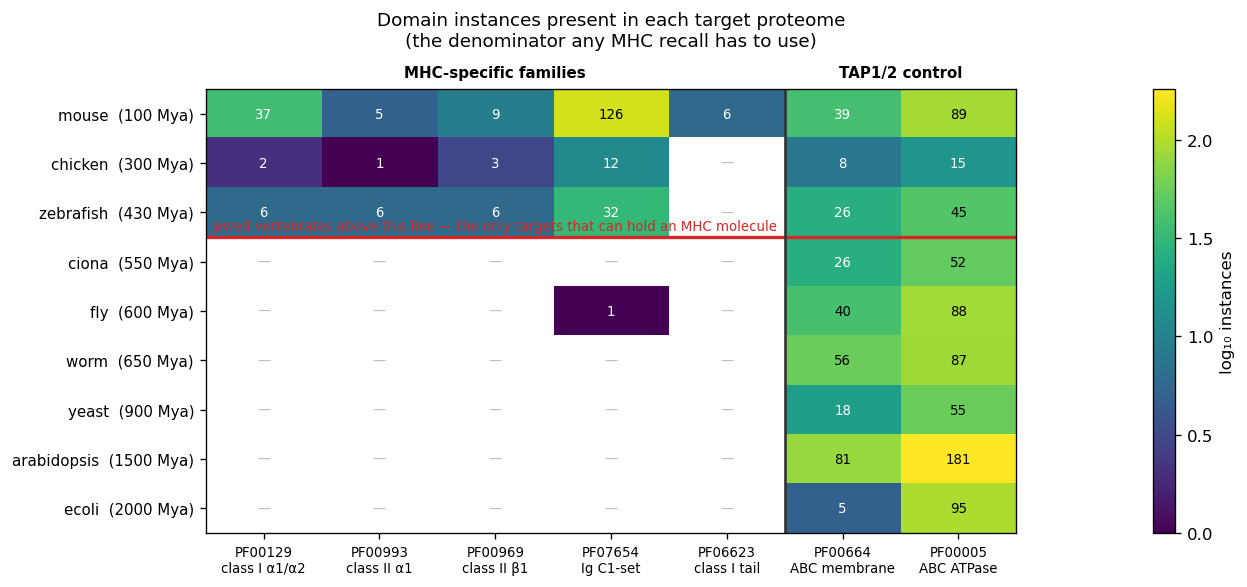

In [4]:
FAMS = (
    list(mu.PFAM_PLATFORM) + [mu.PFAM_IG_C1, mu.PFAM_CLASS_I_TAIL] + list(mu.PFAM_TAP)
)
FAM_LABEL = {
    **{k: f"{k}\n{v}" for k, v in mu.PFAM_PLATFORM.items()},
    mu.PFAM_IG_C1: f"{mu.PFAM_IG_C1}\nIg C1-set",
    mu.PFAM_CLASS_I_TAIL: f"{mu.PFAM_CLASS_I_TAIL}\nclass I tail",
    **{k: f"{k}\n{v}" for k, v in mu.PFAM_TAP.items()},
}

rows = []
for sp in mu.SPECIES_ORDER:
    dm = mu.load_target_domain_map(sp)
    counts = (
        dm.filter(pl.col("pfam_id").is_in(FAMS))
        .group_by("pfam_id")
        .len()
        .rename({"len": "n_instances"})
    )
    d = dict(zip(counts["pfam_id"].to_list(), counts["n_instances"].to_list()))
    rows.append(
        {
            "species": sp,
            "mya": mu.SPECIES_MYA[sp],
            "proteome_domains": dm.height,
            **{f: d.get(f, 0) for f in FAMS},
        }
    )
reach = pl.DataFrame(rows)
with pl.Config(tbl_width_chars=200, tbl_rows=20):
    print(reach)

mat = reach.select(FAMS).to_numpy().astype(float)
fig, ax = plt.subplots(figsize=(10.5, 5.0))
shown = np.where(mat > 0, np.log10(mat), np.nan)
im = ax.imshow(shown, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(FAMS)))
ax.set_xticklabels([FAM_LABEL[f] for f in FAMS], fontsize=8)
ax.set_yticks(range(len(mu.SPECIES_ORDER)))
ax.set_yticklabels(
    [f"{s}  ({mu.SPECIES_MYA[s]} Mya)" for s in mu.SPECIES_ORDER], fontsize=9
)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = int(mat[i, j])
        ax.text(
            j,
            i,
            "—" if v == 0 else f"{v:_}",
            ha="center",
            va="center",
            fontsize=8,
            color="#bbbbbb" if v == 0 else ("white" if shown[i, j] < 1.6 else "black"),
        )
ax.axhline(2.5, color="#D62728", lw=2)
ax.text(
    -0.45,
    2.42,
    "jawed vertebrates above this line — the only targets that can hold an MHC molecule",
    color="#D62728",
    fontsize=8,
    va="bottom",
    ha="left",
)
# The two ABC columns are the control, not MHC families; the divider says so.
ax.axvline(4.5, color="#333333", lw=1.6)
ax.text(2.0, -0.75, "MHC-specific families", ha="center", fontsize=9, fontweight="bold")
ax.text(5.5, -0.75, "TAP1/2 control", ha="center", fontsize=9, fontweight="bold")
ax.set_title(
    "Domain instances present in each target proteome\n(the denominator any MHC recall has to use)",
    fontsize=11,
    pad=26,
)
fig.colorbar(im, ax=ax, label="log₁₀ instances", fraction=0.03, pad=0.14)
fig.tight_layout()
fig.savefig(FIG_DIR / "220_mhc_family_reachability.png", dpi=200)

## 4. What this query set does not cover

Four gaps, stated here so no later notebook has to rediscover them.

**β2-microglobulin is not in the query set.** B2M is on chr15, and the query set is chr6.
Every class I molecule is a heterodimer of a heavy chain and B2M, so "class I" here means
the heavy chain only. `ou.MHC_CLASSES` lists B2M and the midi run cannot score it.

**Only the primary assembly.** GRCh38 carries eight MHC alt haplotypes
(`ou.HUMAN_MHC_ALT_CONTIGS`), and the whole point of the MHC is that haplotypes differ. The
QfO human reference proteome is one allele per gene.

**Class I is a multigene family, and one gene is not one lineage.** HLA-A, -B and -C are a
primate-specific expansion of a single ancestral locus. Six class I heavy chains is three
independent lineages, not six — notebook 215 already made this point and it still applies.

**The structure arms cannot see everything the sequence arms can.** The AlphaFold DB ships
full-length models only to 2,700 aa and this pipeline keeps fragment F1 only, and ProstT5 is
capped at 6,000 aa. That is not binding on MHC genes, which are all under 810 residues — but
it is binding on the chr6 control set, so a tool comparison over all 964 genes has to say so.

B2M in ou.MHC_CLASSES : True
B2M in the query set  : False

Longest curated MHC proteins:
shape: (3, 2)
┌─────────────┬────────────┐
│ hgnc_symbol ┆ n_residues │
│ ---         ┆ ---        │
│ str         ┆ i64        │
╞═════════════╪════════════╡
│ TAP1        ┆ 748        │
│ TAP2        ┆ 686        │
│ TAPBP       ┆ 448        │
└─────────────┴────────────┘
ProstT5 cap 6000 aa, AFDB full-length limit 2700 aa -> MHC genes affected: 0

chr6 control genes over the 2,700 aa AFDB limit: 0 of 957 (0.0%)
shape: (0, 2)
┌─────────────┬────────────┐
│ hgnc_symbol ┆ n_residues │
│ ---         ┆ ---        │
│ str         ┆ i64        │
╞═════════════╪════════════╡
└─────────────┴────────────┘

Class I heavy chains (n=6 genes, 3 independent lineages):
shape: (6, 3)
┌─────────────┬─────────────────┬────────────┐
│ hgnc_symbol ┆ mhc_class       ┆ n_residues │
│ ---         ┆ ---             ┆ ---        │
│ str         ┆ str             ┆ i64        │
╞═════════════╪═════════════════╪══════════

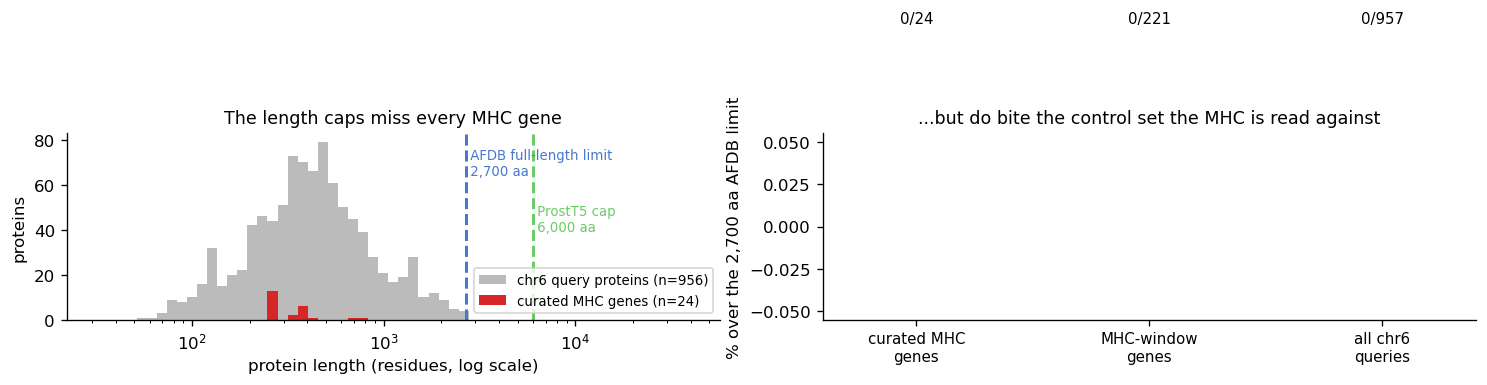

In [5]:
print(f"B2M in ou.MHC_CLASSES : {'B2M' in ou.MHC_CLASSES}")
print(
    f"B2M in the query set  : {gene_map.filter(pl.col('hgnc_symbol') == 'B2M').height > 0}"
)

longest = (
    core.select("hgnc_symbol", "n_residues").sort("n_residues", descending=True).head(3)
)
print("\nLongest curated MHC proteins:")
print(longest)
print(
    f"ProstT5 cap 6000 aa, AFDB full-length limit 2700 aa -> MHC genes affected: "
    f"{core.filter(pl.col('n_residues') > 2700).height}"
)

over = gm.filter(pl.col("n_residues") > 2700)
print(
    f"\nchr6 control genes over the 2,700 aa AFDB limit: {over.height} of {gm.height} "
    f"({100 * over.height / gm.height:.1f}%)"
)
print(
    over.select("hgnc_symbol", "n_residues").sort("n_residues", descending=True).head(5)
)

print("\nClass I heavy chains (n=6 genes, 3 independent lineages):")
print(
    core.filter(pl.col("hgnc_symbol").is_in(ou.MHC_CLASS_I_GENES))
    .select("hgnc_symbol", "mhc_class", "n_residues")
    .sort("hgnc_symbol")
)

# Where the length caps bite. MHC genes are all short; the chr6 control set is not, so a
# tool comparison run over all 964 has to carry this and the MHC figures do not.
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
ax = axes[0]
lengths = gm["n_residues"].drop_nulls().to_numpy()
ax.hist(
    lengths,
    bins=np.logspace(1.5, 4.6, 60),
    color="#bbbbbb",
    label=f"chr6 query proteins (n={len(lengths)})",
)
ax.hist(
    core["n_residues"].drop_nulls().to_numpy(),
    bins=np.logspace(1.5, 4.6, 60),
    color="#D62728",
    label=f"curated MHC genes (n={core.height})",
)
ax.axvline(2700, color="#4878CF", lw=1.8, ls="--")
ax.text(
    2700,
    ax.get_ylim()[1] * 0.92,
    " AFDB full-length limit\n 2,700 aa",
    fontsize=8,
    color="#4878CF",
    va="top",
)
ax.axvline(6000, color="#6ACC65", lw=1.8, ls="--")
ax.text(
    6000,
    ax.get_ylim()[1] * 0.62,
    " ProstT5 cap\n 6,000 aa",
    fontsize=8,
    color="#6ACC65",
    va="top",
)
ax.set_xscale("log")
ax.set_xlabel("protein length (residues, log scale)")
ax.set_ylabel("proteins")
ax.set_title("The length caps miss every MHC gene", fontsize=10.5)
ax.legend(fontsize=8)

ax = axes[1]
groups = ["curated MHC\ngenes", "MHC-window\ngenes", "all chr6\nqueries"]
frames = [core, window, gm]
over = [f.filter(pl.col("n_residues") > 2700).height for f in frames]
tot = [f.height for f in frames]
ax.bar(range(3), [100 * o / t for o, t in zip(over, tot)], 0.55, color="#4878CF")
for i, (o, t) in enumerate(zip(over, tot)):
    ax.text(i, 100 * o / t + 0.12, f"{o}/{t}", ha="center", fontsize=9)
ax.set_xticks(range(3))
ax.set_xticklabels(groups, fontsize=9)
ax.set_ylabel("% over the 2,700 aa AFDB limit")
ax.set_title("...but do bite the control set the MHC is read against", fontsize=10.5)
for a in axes:
    for s_ in ("right", "top"):
        a.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "220_length_caps.png", dpi=200)

## Summary

The midi run puts **964 human chr6 proteins** against nine proteomes. **221** of them fall
inside the extended MHC; **736** are the same-chromosome control that every later comparison
is read against, and 7 could not be placed.

Inside the MHC, the run scores **24 curated MHC genes** carrying **51 Pfam domain
instances**. The architecture is uniform and it is what makes the region worth studying with
this pipeline: every class I and class II gene is a **fast-evolving peptide-binding platform
bolted to a conserved Ig C1-set domain**, searched together, scored together, under opposite
selection. TAP1/TAP2's ABC-transporter domains sit in the same region as a control that
reaches all the way to *E. coli*.

The denominator is not flat. Only **mouse, chicken and zebrafish** contain MHC platform
domains at all. Beyond them a hit is a claim about the fold, not about an MHC molecule, and
notebooks 221–223 keep that line visible rather than averaging across it.